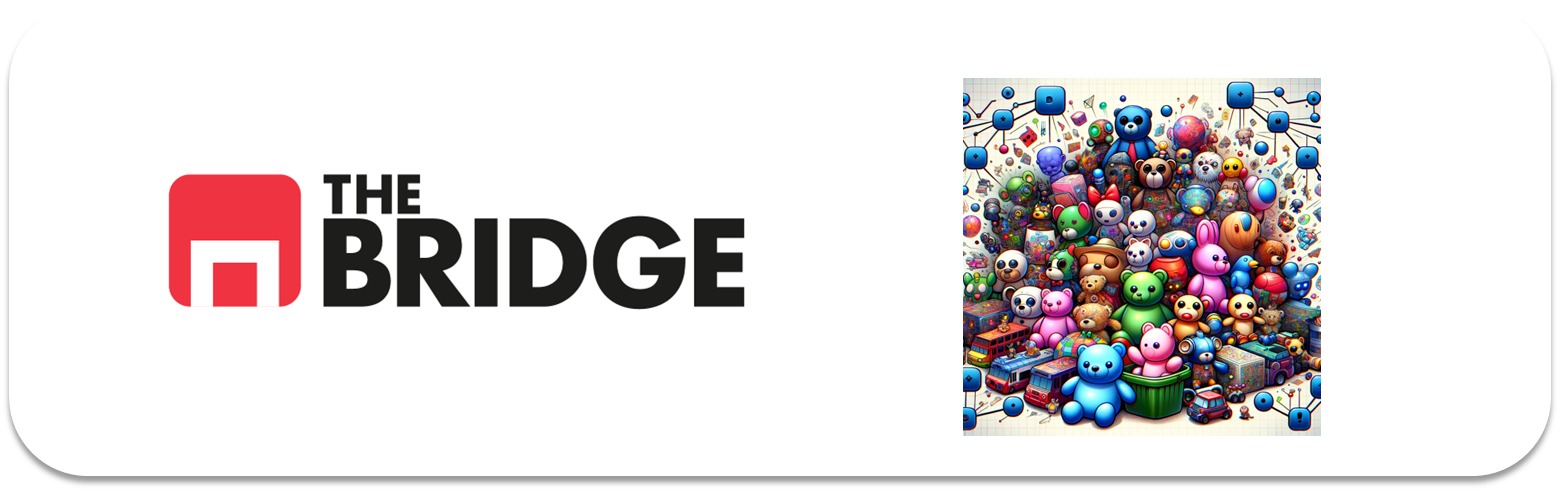

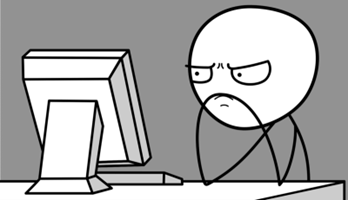

Para ejercitarte y afianzar lo aprendido sobre **Clustering Jerárquico**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Descripción del "Problema"

Existen disponibles datos de encuestas y cuestionarios a 26 instituciones. Estas instituciones han sido evaluadas bajo distintos criterios de desempeño, como profesorado, costos, ubicación, becas e infraestructura. Cada criterio va del 1 al 5, siendo 5 el mayor.

El objetivo principal será segmentar las instituciones en grupos basásndonos en los criterios antes mencionados, y luego generar descripciones y recomendaciones a seguir con respecto a cada uno de los grupos identificados. Las recomendaciones pueden ser para distintos clientes.
    </div>

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### Ejercicio 1

Carga los datos ("Engg_College_Data") y haz una primera inspección "rápida".

In [2]:
df = pd.read_csv("./data/Engg_College_Data.csv")
df.head()

,SR_NO,Engg_College,Teaching,Fees,Placements,Internship,Infrastructure
0,1,A,5,2,5,5,3
1,2,B,4,2,5,5,3
2,3,C,4,5,5,4,5
3,4,D,5,4,5,4,4
4,5,E,2,5,2,2,5


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SR_NO,26.0,13.500000,7.648529,1.0,7.25,13.5,19.75,26.0
Teaching,26.0,2.807692,1.132051,1.0,2.00,3.0,3.00,5.0
Fees,26.0,3.576923,1.331858,1.0,2.25,4.0,5.00,5.0
Placements,26.0,2.884615,1.531716,1.0,1.25,3.0,4.00,5.0
Internship,26.0,2.769231,1.242826,1.0,2.00,2.0,4.00,5.0
Infrastructure,26.0,3.384615,1.298520,1.0,3.00,3.0,4.75,5.0


In [4]:
# Están en escalas similares así que no hay que necesariamente utilizar un Scaler para escalar los datos

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   SR_NO           26 non-null     int64
 1   Engg_College    26 non-null     str  
 2   Teaching        26 non-null     int64
 3   Fees            26 non-null     int64
 4   Placements      26 non-null     int64
 5   Internship      26 non-null     int64
 6   Infrastructure  26 non-null     int64
dtypes: int64(6), str(1)
memory usage: 1.6 KB


### Ejercicio 2

Crea un train_set con una única variable de tipo índice (que nos servirá para identifcar a las instituciones en cada clúster)

In [6]:
df.index
df.columns

Index(['SR_NO', 'Engg_College', 'Teaching', 'Fees', 'Placements', 'Internship',
       'Infrastructure'],
      dtype='str')

In [7]:
train_set = df[["Engg_College"]].copy()

train_set.columns = ["Institution"]

### Ejercicio 3

Determina el tipo de cada variable, haciendo un univariante de las mismas.

In [8]:
num_cols = df.select_dtypes(include="number").columns.to_list()

cat_cols = df.select_dtypes(include=["category", "object"]).columns.to_list()

print("Categórics:", cat_cols)
print("=" * 75)
print("Numéricas:", num_cols)

Categórics: ['Engg_College']
Numéricas: ['SR_NO', 'Teaching', 'Fees', 'Placements', 'Internship', 'Infrastructure']


/var/folders/0g/ltyf2qv91t9_1979pghhp9fh0000gn/T/ipykernel_9588/2408628620.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["category", "object"]).columns.to_list()


In [9]:
df["Engg_College"].value_counts()

#La variable Engg_College presenta valores únicos para cada observación, 
# como se observa en el análisis de frecuencias donde todas las categorías tienen frecuencia 1. 
# Por tanto, actúa como un identificador nominal de las instituciones y no representa una característica medible relevante para el análisis. 
# Esta variable no se utilizará como entrada en el proceso de clustering, aunque se conservará para identificar las instituciones en cada grupo resultante.

Engg_College
A    1
B    1
C    1
D    1
E    1
F    1
G    1
H    1
I    1
J    1
K    1
L    1
M    1
N    1
O    1
P    1
Q    1
R    1
S    1
T    1
U    1
V    1
W    1
X    1
Y    1
Z    1
Name: count, dtype: int64

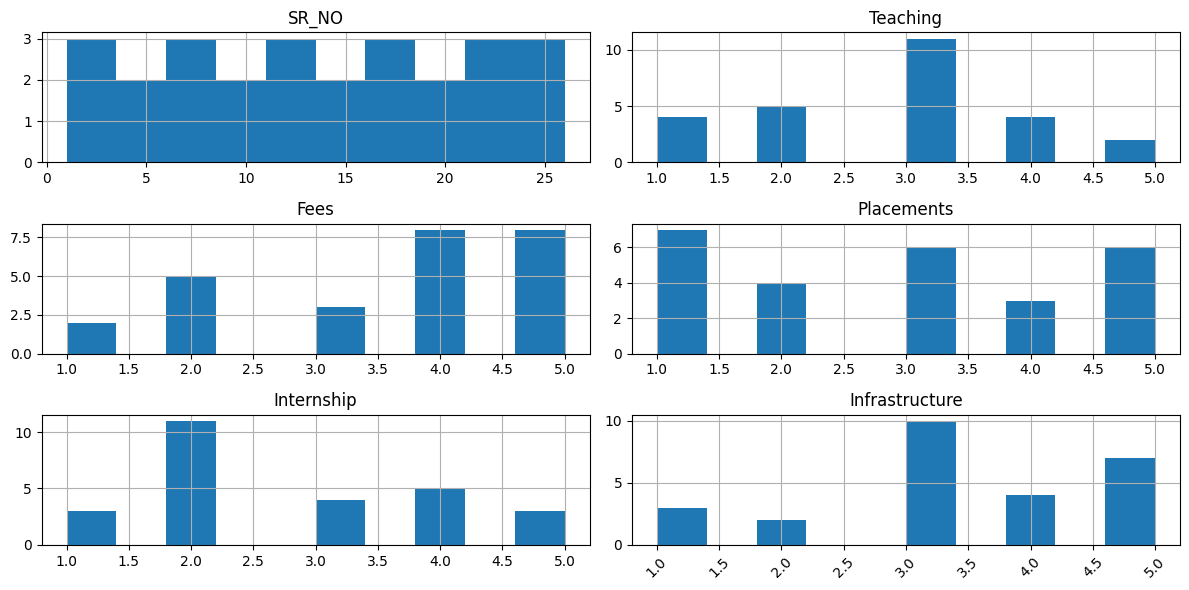

In [10]:
df[num_cols].hist(figsize=(12,6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show();

### Ejercicio 4

Es hora de hacer el miniEDA. Fíjate que en este caso no tenemos contínuas numéricas que nos permitan ver claramente una clusterización con scatter plots. Compruébalo haciendo un pairplot del dataset.

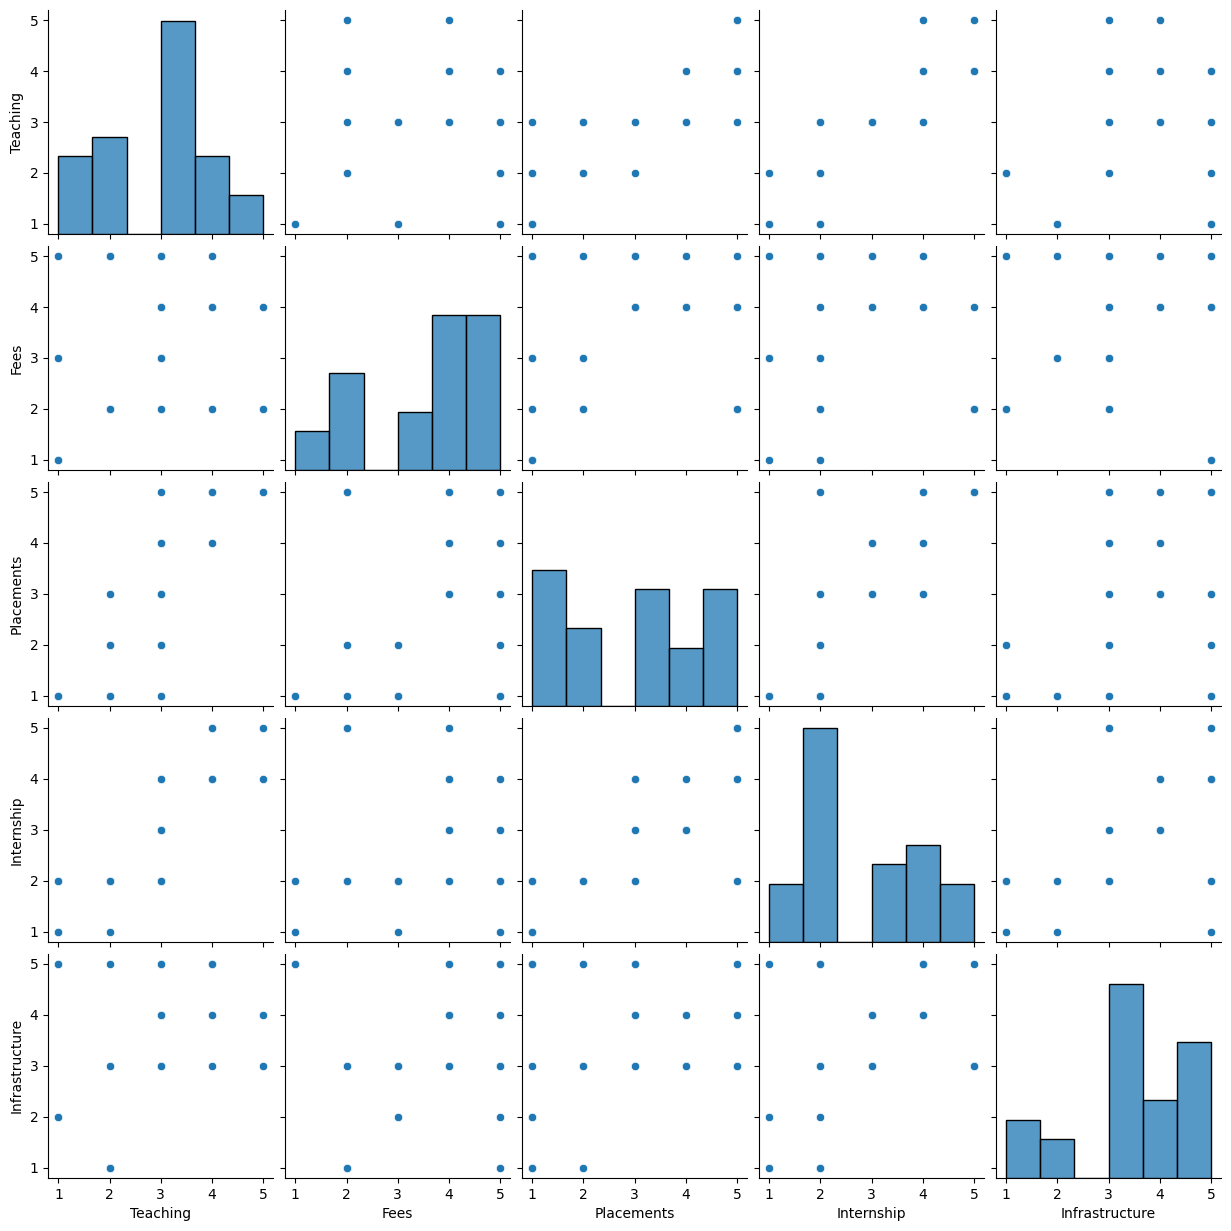

In [11]:
pairplot_cols = [col for col in num_cols if col != "SR_NO"]

sns.pairplot(df[pairplot_cols])

In [12]:
# El pairplot muestra concentraciones muy rigidas con espacios vacíos entre si
# Mostrandose como casi un grid, ordenados y en lineas estructuradas, lo que puede demostrar agrupaciones naturalmente ocurrientes
# Esto puede demostrarnos también el valor detrás del uso de modelos basados en clustering 
# para identificar grupos de instituciones con características similares en términos de desempeño académico, infraestructura y resultados.

### Ejercicio 5

Podríamos intentar cualquier tipo de clusterización, pero vamos a emplear una clusterización jerárquica porque sea cual sea la agrupación si que nos interesa establecer una jerarquía o una relación de distancia entre las diferentes instituciones (es algo que nos dicen desde el cliente, o sea "Negocio")

Elegido el tipo de clustering, tenemos que determinar los hiperparámetros. En este caso, el número de clusteres. Para ello nos vamos a apoyar en el dendrograma. Construye el dendrograma utilizando "average" como el método de ligado o linkage.



NOTA: no lo hemos hecho, ni dicho, pero nos quedaremos con todas las variables para sean features y como están en la misma escala no hay que procesarlas otra vez.

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df[pairplot_cols]

X_scaled = scaler.fit_transform(X)

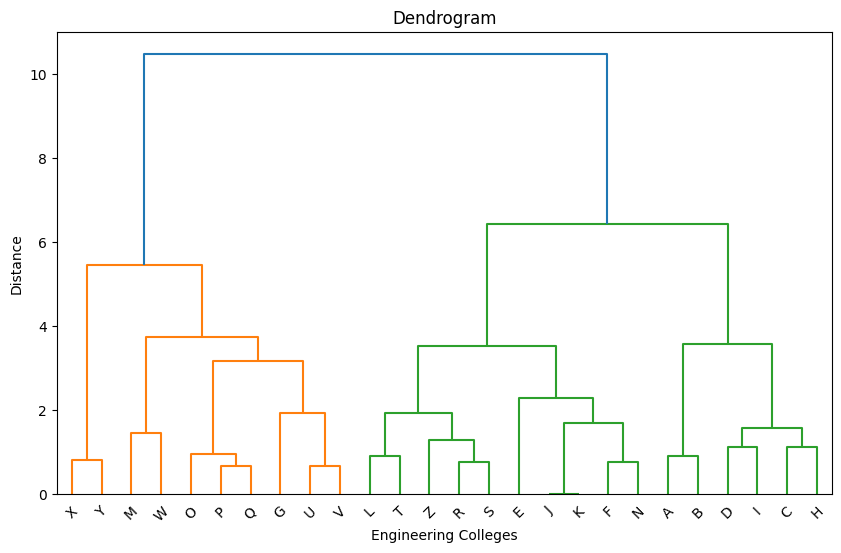

In [17]:
import scipy.cluster.hierarchy as shc

plt.figure(figsize=(10,6))
shc.dendrogram(shc.linkage(X_scaled, method="ward"),
               labels = df["Engg_College"].values)
plt.title("Dendrogram")
plt.xlabel("Engineering Colleges")
plt.ylabel("Distance")
plt.show();

### Ejercicio 6

Utilizando el método del máximo salto horizontal o método del máximo gap, ¿dónde colocarías la recta de corte? Vuelve a dibujar el dendrograma superponiendo esa línea. Decide el número de clusteres.

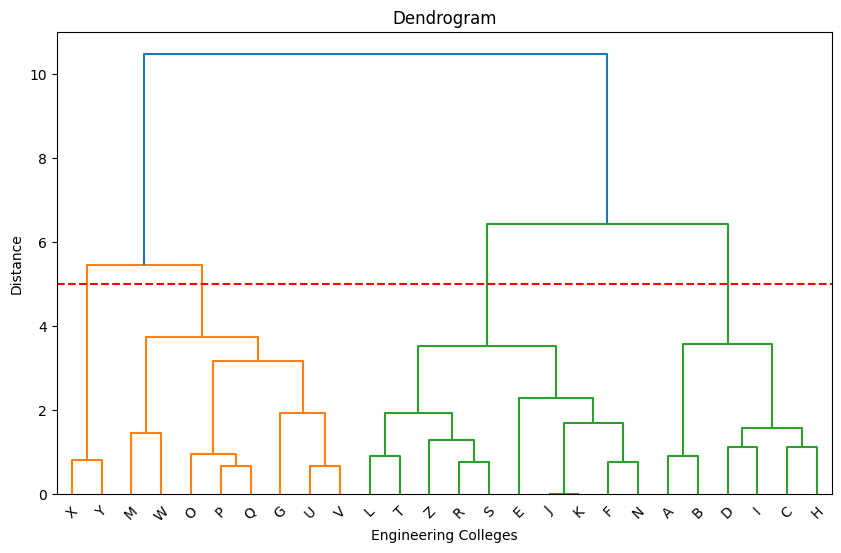

In [18]:
plt.figure(figsize=(10,6))
shc.dendrogram(shc.linkage(X_scaled, method="ward"),
               labels = df["Engg_College"].values)
plt.axhline(y=5, color='red', linestyle='--') 
plt.title("Dendrogram")
plt.xlabel("Engineering Colleges")
plt.ylabel("Distance")
plt.show();

In [ ]:
# Yo pondría el corte en 5, ya que es un punto donde se observa una separación clara entre los grupos, lo que sugiere la formación de clusters distintos.

### Ejercicio 7

Utilizando el codigo siguiente, emplea el número de clústeres obtenidos en el ejercicio anterior (usa 4 si no has logrado obtener un número que te convenza) y muestra cuántas instituciones hay por cluster. ¿Qué te llama la atención?

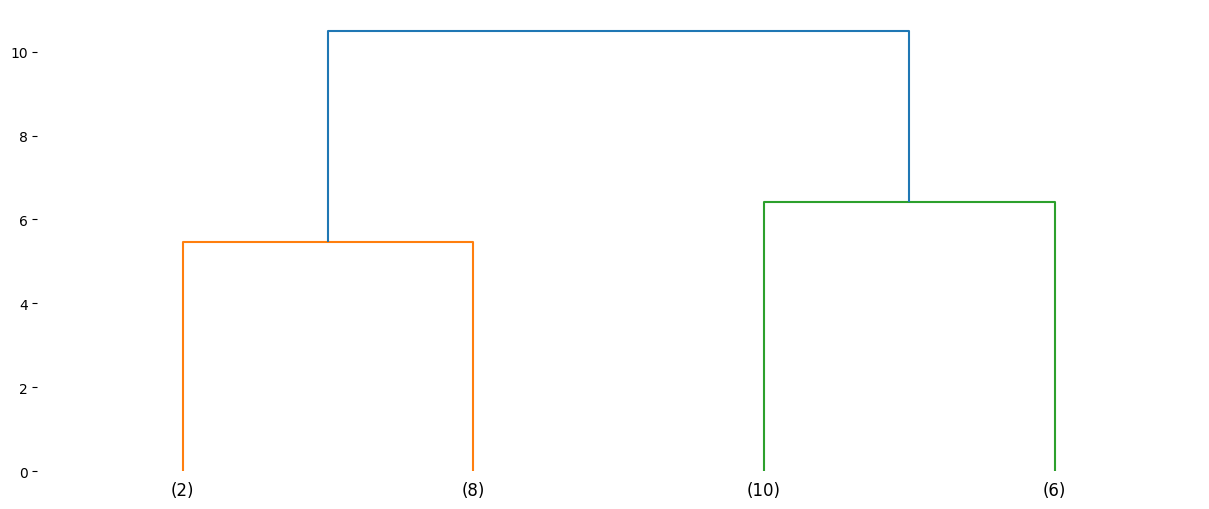

In [25]:
#Miramos cuantos elementos hay en cada cluster
plt.figure(figsize =(15,6))
dend = shc.dendrogram(shc.linkage(X_scaled, method="ward"),
                 truncate_mode='lastp',
                 p = 4, # SUSTITUYE AQUI
                 labels = df["Engg_College"].values
                 )
sns.despine(left=True, bottom=True)

In [ ]:
# En este dendrograma truncado, se observa que al cortar a una distancia de 5, se forman 4 clusters distintos.
# Cada cluster agrupa a instituciones que comparten características similares
# Al fondo vemos los numeros de cada institución, lo que nos permite identificar qué instituciones pertenecen a cada cluster.

### Ejercicio 8

Previo a analizar las características específicas de cada clúster, analiza el clúster con menor número de elementos, es decir muestra las características de sus elementos constituyentes

In [26]:
from scipy.cluster.hierarchy import fcluster

clusters = fcluster(shc.linkage(X_scaled, method="ward"), t=5, criterion='distance')

train_set["Cluster"] = clusters

train_set["Cluster"].value_counts()

Cluster
3    10
2     8
4     6
1     2
Name: count, dtype: int64

In [27]:
smallest_cluster = train_set["Cluster"].value_counts().idxmin()

train_set[train_set["Cluster"] == smallest_cluster]

,Institution,Cluster
23,X,1
24,Y,1


In [28]:
df.loc[df["Engg_College"].isin(["X", "Y"]), X.columns]

,Teaching,Fees,Placements,Internship,Infrastructure
23,1,1,1,2,5
24,1,1,1,1,5


In [ ]:
# El clúster con menor número de instituciones está formado por X y Y. 
# Estas instituciones presentan valores muy bajos en Teaching, Fees, Placements e Internship, pero valores elevados en Infrastructure. 
# Este perfil atípico las diferencia claramente del resto del conjunto, lo que explica que el algoritmo de Ward las haya agrupado en un clúster independiente.

### Ejercicio 9

Nos hemos adelantado en el ejercicio anterior. Es hora de construir el clustering tal como hemos visto en el workout, utiliza el "AgglomerativeClustering" de sklearn para hacer el agrupamiento con el número de clusteres elegido y asigna las etiquetas a cada instancia. (Recuerda que hemos usado el linkage a "average", no a "ward" como se suele emplear)

In [30]:
from sklearn.cluster import AgglomerativeClustering

n_clusters = 4

agg_cluster = AgglomerativeClustering(n_clusters=n_clusters, linkage='average')

labels = agg_cluster.fit_predict(X_scaled)

In [31]:
train_set["Cluster_Agglo"] = labels

train_set["Cluster_Agglo"].value_counts()

Cluster_Agglo
1    14
0     8
3     2
2     2
Name: count, dtype: int64

In [ ]:
# Con el método de linkage "average", se obtienen 4 clusters con una distribución de 14, 8, 2 y 2 instituciones respectivamente.
# Parece agrupar un número mayor en algunas categorías, pero no se observa una diferencia clara en la distribución de los clusters en comparación con el método de Ward.

### Ejercicio 10

Comprueba que las instancias asignadas al clúster con 2 instancias son las entidades "X" e "Y"

In [34]:
smallest_cluster_agglo = train_set["Cluster_Agglo"].value_counts().idxmin()

train_set[train_set["Cluster_Agglo"] == smallest_cluster_agglo]


,Institution,Cluster,Cluster_Agglo
0,A,4,3
1,B,4,3


In [35]:
train_set[train_set["Cluster_Agglo"] == 2]

,Institution,Cluster,Cluster_Agglo
23,X,1,2
24,Y,1,2


In [39]:
df.loc[df["Engg_College"].isin(["A", "B", "X", "Y"]), X.columns]

,Teaching,Fees,Placements,Internship,Infrastructure
0,5,2,5,5,3
1,4,2,5,5,3
23,1,1,1,2,5
24,1,1,1,1,5


### Ejercicio 11

Igual que podemos intuir que el cluster "pequeño" es el de las instituiciones peor puntuadas, muestra los valores medios de las features para cada clúster y da tu interpretación de que es cada uno. Emplea un gráfico comparativo.


In [43]:
df["Cluster_Agglo"] = train_set["Cluster_Agglo"]

cluster_mean = df.groupby("Cluster_Agglo")[X.columns].mean()
cluster_mean

,Teaching,Fees,Placements,Internship,Infrastructure
Cluster_Agglo,,,,,
0,2.125000,3.125000,1.375000,1.750000,2.0
1,3.214286,4.428571,3.714286,3.214286,4.0
2,1.000000,1.000000,1.000000,1.500000,5.0
3,4.500000,2.000000,5.000000,5.000000,3.0


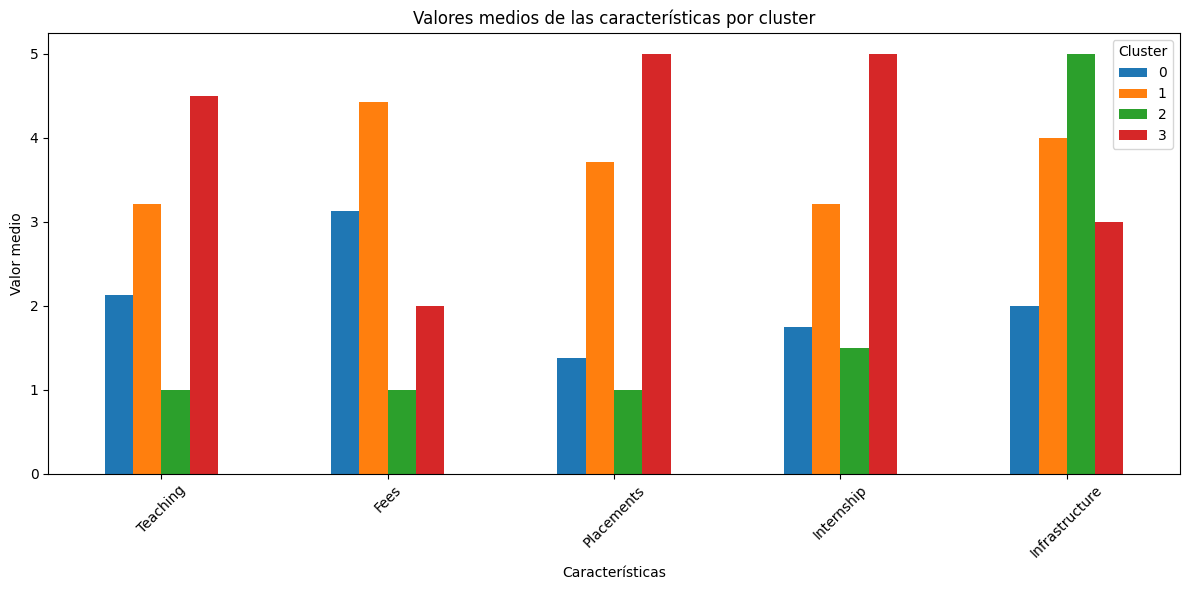

In [ ]:
cluster_mean.T.plot(kind="bar", figsize=(12,6))
plt.title("Valores medios de las características por cluster")
plt.xlabel("Características")
plt.ylabel("Valor medio")
plt.legend(title="Cluster")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show(); 

### Ejercicio 12

Para finalizar, ¿qué recomendaciones darías a diferentes clientes en base a los patrones encontrados?

* Grupo 3 - Para el cliente en el grupo 3, el cual tiene alta puntuación en casi todo, un poco menos en infraestructura con matrícula muy baja pudieran subirla medianamente e invertirla en la infraestructura para así posicionarse como una institución elite.

* Grupo 2 - El grupo 2 tiene una puntuación muy alta en insfraestructura mientras que carece de buenos resultados académicos, profesorado, etc. 
Por lo que yo recomendaría utilizar la gran insfraestructura para generar dinero que pueda ir hacia mejor profesorado, mejores recursos académicos, partnerships para mejores internships, etc. 
Esto se puede llevar a cabo alquilando sus espacios físicos para actividades como el estadio, auditoriums, etc. 
- También podrían utilizar su infraestructura para marketing, de manera que atraigan mejores estudiantes y mejor profesodado, etc.

* Grupo 1 - El grupo 1 es más homogeneo, así que es un poco más difícil hacer recomendaciones. 
Podrían invertir menos en su infraestructura de manera que pueden redirigir ese dinero e invertirlo en mejor profesodaro. Lo cual haría los precios de matrícula más justificables.
- También podrían hacer uso de su buena infraestructura para atraer estudiantes más competitivos y mejor profesorado.

* Grupo 0 - Me enfocaría en invertir en placements y en mejores interships, que son los que puntúan más bajo dentro de todas las metricas. También en bajar la matrícula medianamente, pero solo cuando haya mejora en la parte académica, en los placements y los interships.